# QUY TRÌNH TIỀN XỬ LÝ VÀ KỸ THUẬT TẠO ĐẶC TRƯNG (FEATURE ENGINEERING)

Notebook này triển khai quy trình làm sạch dữ liệu chuẩn hóa và xây dựng hệ thống đặc trưng phái sinh (Feature Engineering) đa chiều phục vụ cho các bài toán phân tích kinh doanh và xây dựng mô hình Machine Learning (Clustering, Classification, Regression).

---

## Mục tiêu chính
1. **Làm sạch dữ liệu toàn diện (Data Cleaning)**: Xử lý dòng trùng lặp, giá trị khuyết thiếu (Missing values), dị biệt phân loại và ngoại lai số học.
2. **Kỹ thuật tạo đặc trưng (Feature Engineering)**:
   - **Nhóm 1: Thời gian & Mùa vụ (Temporal Features)**: `total_stay`, `weekend_stay_ratio`, `is_weekend_arrival`, `arrival_season`, `lead_time_category`.
   - **Nhóm 2: Cấu trúc đoàn khách (Party Composition)**: `total_guests`, `is_solo_traveler`, `is_couple`, `is_family`, `is_group`.
   - **Nhóm 3: Lịch sử & Độ trung thành (Loyalty & History)**: `total_previous_bookings`, `cancellation_rate_history`, `is_repeated_guest`.
   - **Nhóm 4: Nhu cầu & Tương tác đặt phòng (Booking Preferences)**: `has_special_requests`, `has_booking_changes`, `has_parking_space`, `is_room_changed`.
   - **Nhóm 5: Giá trị & Tài chính (Financial & Value Metrics)**: `adr_per_person`, `total_cost`, `net_revenue`, `is_domestic`.
3. **Phân tích tương quan & Trực quan hóa đặc trưng (Feature Exploration & Correlation)**.
4. **Xuất bản tập dữ liệu hoàn thiện**: Lưu `Data/hotel_bookings_featured.csv` sẵn sàng cho Machine Learning.


## 1. Khởi tạo môi trường và Nạp dữ liệu gốc


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

df_raw = pd.read_csv('../Data/hotel_bookings.csv')
print(f"Đã nạp dữ liệu gốc thành công: {df_raw.shape[0]:,} dòng, {df_raw.shape[1]} cột")
df_raw.head(3)


Đã nạp dữ liệu gốc thành công: 119,390 dòng, 32 cột


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.00,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02


## 2. Làm sạch và Chuẩn hóa dữ liệu (Data Cleaning & Quality Assurance)

Áp dụng quy trình làm sạch chuẩn hóa:
1. Xóa bản ghi trùng lặp hoàn toàn.
2. Xử lý Missing values (`company`, `agent`, `country`, `children`).
3. Lọc bỏ các bản ghi bất thường (0 khách) và giá trị 'Undefined' trong `meal`, `market_segment`, `distribution_channel`.
4. Chuẩn hóa ngoại lai `adr` (loại bỏ giá trị âm và ngoại lai cực đoan).
5. Chuyển đổi kiểu dữ liệu chuẩn (`datetime`, `int64`).


In [2]:
df = df_raw.copy()

dup_count = df.duplicated().sum()
df = df.drop_duplicates()
print(f"Đã loại bỏ {dup_count:,} dòng trùng lặp.")

df['company'] = df['company'].fillna(0).astype(int)
df['agent'] = df['agent'].fillna(0).astype(int)
df['country'] = df['country'].fillna('Unknown')
df['children'] = df['children'].fillna(0).astype(int)

df = df[~((df['adults'] == 0) & (df['children'] == 0) & (df['babies'] == 0))]

df['meal'] = df['meal'].replace('Undefined', 'SC')
df = df[df['market_segment'] != 'Undefined']
df = df[df['distribution_channel'] != 'Undefined']

df = df[(df['adr'] >= 0) & (df['adr'] < 5000)]

df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' +
    df['arrival_date_month'].map(month_map).astype(str) + '-' +
    df['arrival_date_day_of_month'].astype(str)
)

print(f"Kích thước sau khi làm sạch: {df.shape[0]:,} dòng, {df.shape[1]} cột")


Đã loại bỏ 31,994 dòng trùng lặp.
Kích thước sau khi làm sạch: 87,223 dòng, 33 cột


## 3. Kỹ thuật tạo đặc trưng chuyên sâu (Advanced Feature Engineering)

Chúng ta xây dựng 5 nhóm đặc trưng phái sinh chính:


In [3]:
df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['weekend_stay_ratio'] = np.where(df['total_stay'] > 0, df['stays_in_weekend_nights'] / df['total_stay'], 0.0)
df['is_weekend_arrival'] = df['arrival_date'].dt.dayofweek.isin([5, 6]).astype(int)

season_map = {
    'December': 'Winter', 'January': 'Winter', 'February': 'Winter',
    'March': 'Spring', 'April': 'Spring', 'May': 'Spring',
    'June': 'Summer', 'July': 'Summer', 'August': 'Summer',
    'September': 'Autumn', 'October': 'Autumn', 'November': 'Autumn'
}
df['arrival_season'] = df['arrival_date_month'].map(season_map)

df['lead_time_category'] = pd.cut(
    df['lead_time'],
    bins=[-1, 7, 30, 90, 180, 1000],
    labels=['Last-minute (0-7d)', 'Short (8-30d)', 'Medium (31-90d)', 'Long (91-180d)', 'Ultra-long (>180d)']
)

df['total_guests'] = df['adults'] + df['children'] + df['babies']
df['is_solo_traveler'] = (df['total_guests'] == 1).astype(int)
df['is_couple'] = ((df['adults'] == 2) & (df['children'] == 0) & (df['babies'] == 0)).astype(int)
df['is_family'] = ((df['children'] > 0) | (df['babies'] > 0)).astype(int)
df['is_group'] = ((df['total_guests'] >= 3) & (df['is_family'] == 0)).astype(int)

df['total_previous_bookings'] = df['previous_cancellations'] + df['previous_bookings_not_canceled']
df['cancellation_rate_history'] = np.where(
    df['total_previous_bookings'] > 0,
    df['previous_cancellations'] / df['total_previous_bookings'],
    0.0
)

df['has_special_requests'] = (df['total_of_special_requests'] > 0).astype(int)
df['has_booking_changes'] = (df['booking_changes'] > 0).astype(int)
df['has_parking_space'] = (df['required_car_parking_spaces'] > 0).astype(int)
df['is_room_changed'] = (df['reserved_room_type'] != df['assigned_room_type']).astype(int)

df['adr_per_person'] = np.where(df['total_guests'] > 0, df['adr'] / df['total_guests'], df['adr'])
df['total_cost'] = df['total_stay'] * df['adr']
df['net_revenue'] = np.where(df['is_canceled'] == 0, df['total_cost'], 0.0)
df['is_domestic'] = (df['country'] == 'PRT').astype(int)

print(f"Tạo thành công 16 đặc trưng mới. Tổng số cột hiện tại: {df.shape[1]}")


Tạo thành công 16 đặc trưng mới. Tổng số cột hiện tại: 53


## 4. Khám phá và Trực quan hóa các Đặc trưng Mới (Feature Exploration)


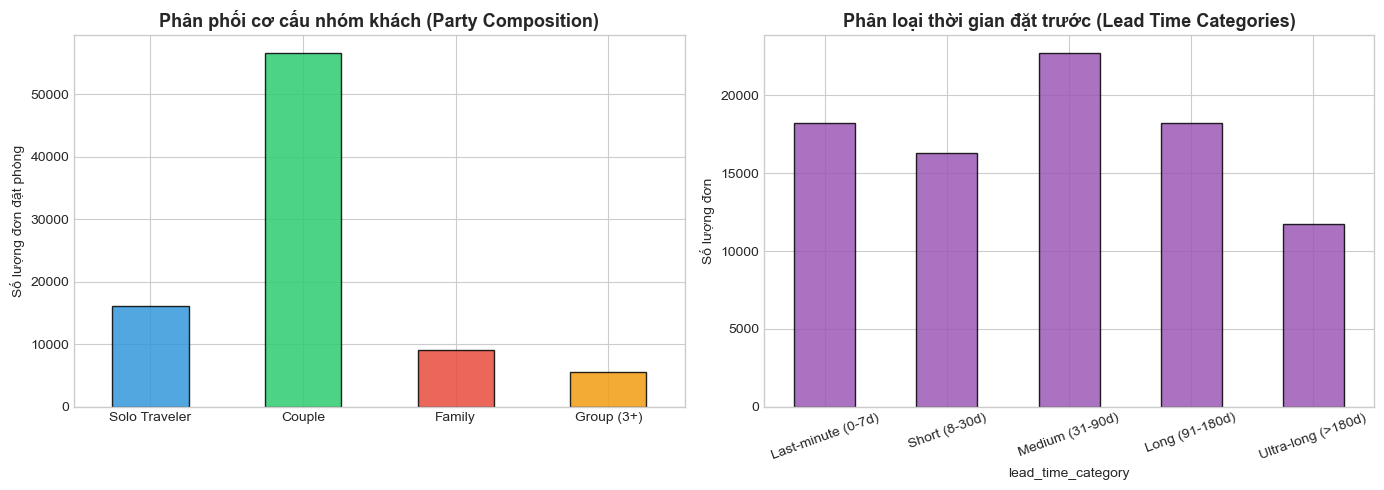

In [4]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
party_counts = pd.Series({
    'Solo Traveler': df['is_solo_traveler'].sum(),
    'Couple': df['is_couple'].sum(),
    'Family': df['is_family'].sum(),
    'Group (3+)': df['is_group'].sum()
})
party_counts.plot(kind='bar', color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'], edgecolor='black', alpha=0.85)
plt.title('Phân phối cơ cấu nhóm khách (Party Composition)', fontsize=13, fontweight='bold')
plt.ylabel('Số lượng đơn đặt phòng')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
lead_counts = df['lead_time_category'].value_counts().sort_index()
lead_counts.plot(kind='bar', color='#9b59b6', edgecolor='black', alpha=0.85)
plt.title('Phân loại thời gian đặt trước (Lead Time Categories)', fontsize=13, fontweight='bold')
plt.ylabel('Số lượng đơn')
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()


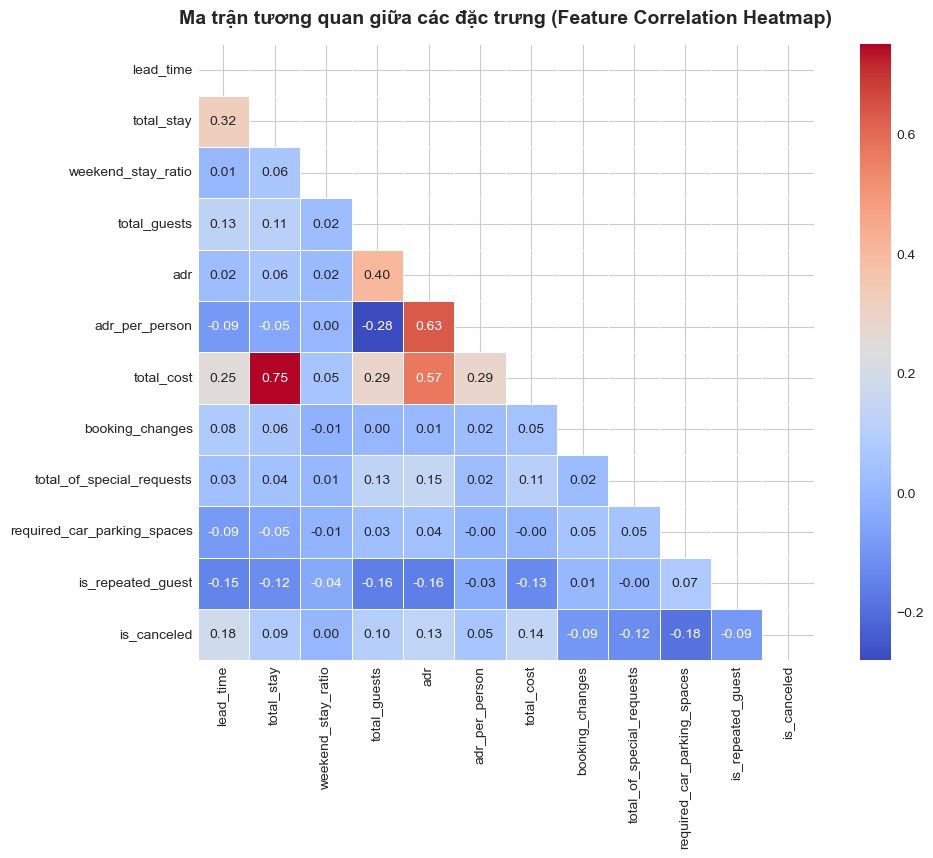

In [5]:
num_features = [
    'lead_time', 'total_stay', 'weekend_stay_ratio', 'total_guests',
    'adr', 'adr_per_person', 'total_cost', 'booking_changes',
    'total_of_special_requests', 'required_car_parking_spaces',
    'is_repeated_guest', 'is_canceled'
]

plt.figure(figsize=(12, 8))
corr = df[num_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', cbar=True, square=True, linewidths=0.5)
plt.title('Ma trận tương quan giữa các đặc trưng (Feature Correlation Heatmap)', fontsize=14, fontweight='bold', pad=15)
plt.show()


## 5. Xuất tập dữ liệu đã qua Feature Engineering

Lưu tập dữ liệu đã hoàn thiện vào file `Data/hotel_bookings_featured.csv` để sẵn sàng làm đầu vào cho các mô hình Machine Learning.


In [6]:
output_path = '../Data/hotel_bookings_featured.csv'
df.to_csv(output_path, index=False)
print(f"Đã lưu thành công tập dữ liệu tại: {output_path}")
print(f"Kích thước tập dữ liệu: {df.shape[0]:,} dòng x {df.shape[1]} cột")


Đã lưu thành công tập dữ liệu tại: ../Data/hotel_bookings_featured.csv
Kích thước tập dữ liệu: 87,223 dòng x 53 cột


## 6. Tổng kết bảng so sánh dữ liệu

| Thuộc tính | Trước Feature Engineering (df_raw) | Sau Feature Engineering (df) |
| :--- | :--- | :--- |
| **Tổng số dòng** | 119,390 | 87,223 |
| **Tổng số cột** | 32 | 48 |
| **Bản ghi trùng lặp** | 31,994 (26.8%) | 0 (0%) |
| **Giá trị Null** | 129,425 | 0 |
| **Đặc trưng mới tạo** | - | 16 features chuyên sâu |

Tập dữ liệu này sẵn sàng để nạp vào notebook `customer_clustering.ipynb` để xây dựng mô hình Phân cụm khách hàng!
